# FORC Smoothing

This notebook assumes the workflow in [FORC_processing.ipynb](./FORC_processing.ipynb) and
the conventions set out in [the chapter introduction](./FORC_intro.md). Where a single
smoothing level cannot serve the whole diagram, continue to
[FORC_variforc.ipynb](./FORC_variforc.ipynb).


Smoothing is the consequential analytical choice in FORC processing. Because the
distribution is a second derivative of measured data, it cannot be estimated without
smoothing, and the level chosen changes the answer.

This notebook leads with the practical recipe and then justifies it:

1. **A recipe**: sweep `smooth_strength`, check which features persist, and report the
   level used.
2. **The neighbourhood**: what the local regression actually averages over, and how much
   of it is usable near the B<sub>c</sub> = 0 axis.
3. **How the window is chosen** by `guess_loess_params`.
4. **What over- and under-smoothing do** to a feature whose true width is known.
5. **A residual criterion** for choosing a level, of the kind FORCinel uses.
6. **What spatially variable smoothing would add**, as VARIFORC implements.

It builds on [FORC_processing.ipynb](./FORC_processing.ipynb), which covers reading,
drift correction, archiving and the standard workflow.

## Install and import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import pmagpy.forc as forc

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. A recipe

If you only want a defensible smoothing level for a real specimen, this is the whole
procedure: compute the distribution at several `smooth_strength` values, keep the features
that persist across them, and report the spans that produced the figure you publish.

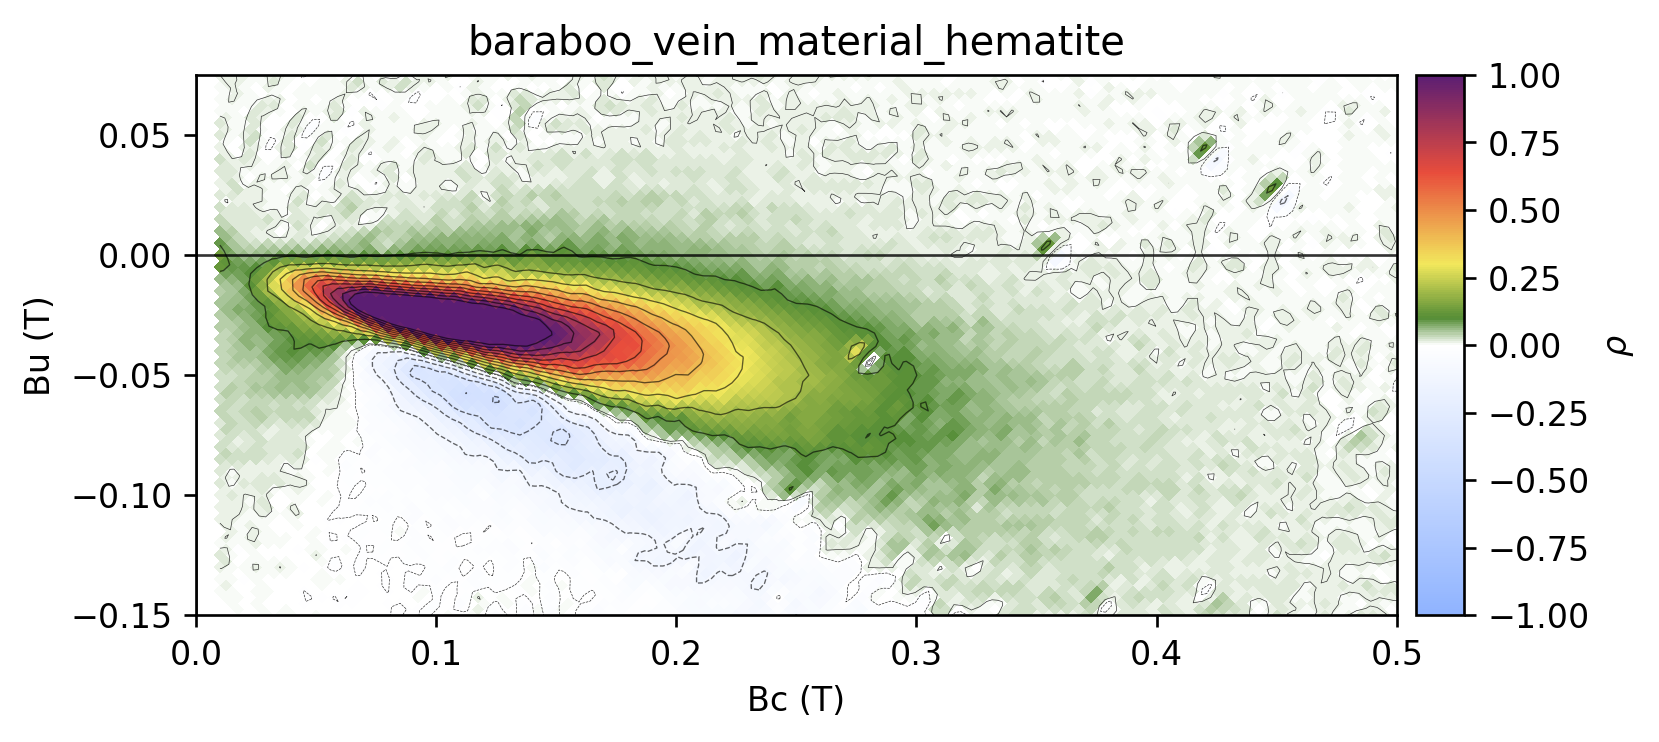

smooth_strength = 0.5: span 13 mT, peak at Bc = 102.5 mT, Bu = -27.5 mT


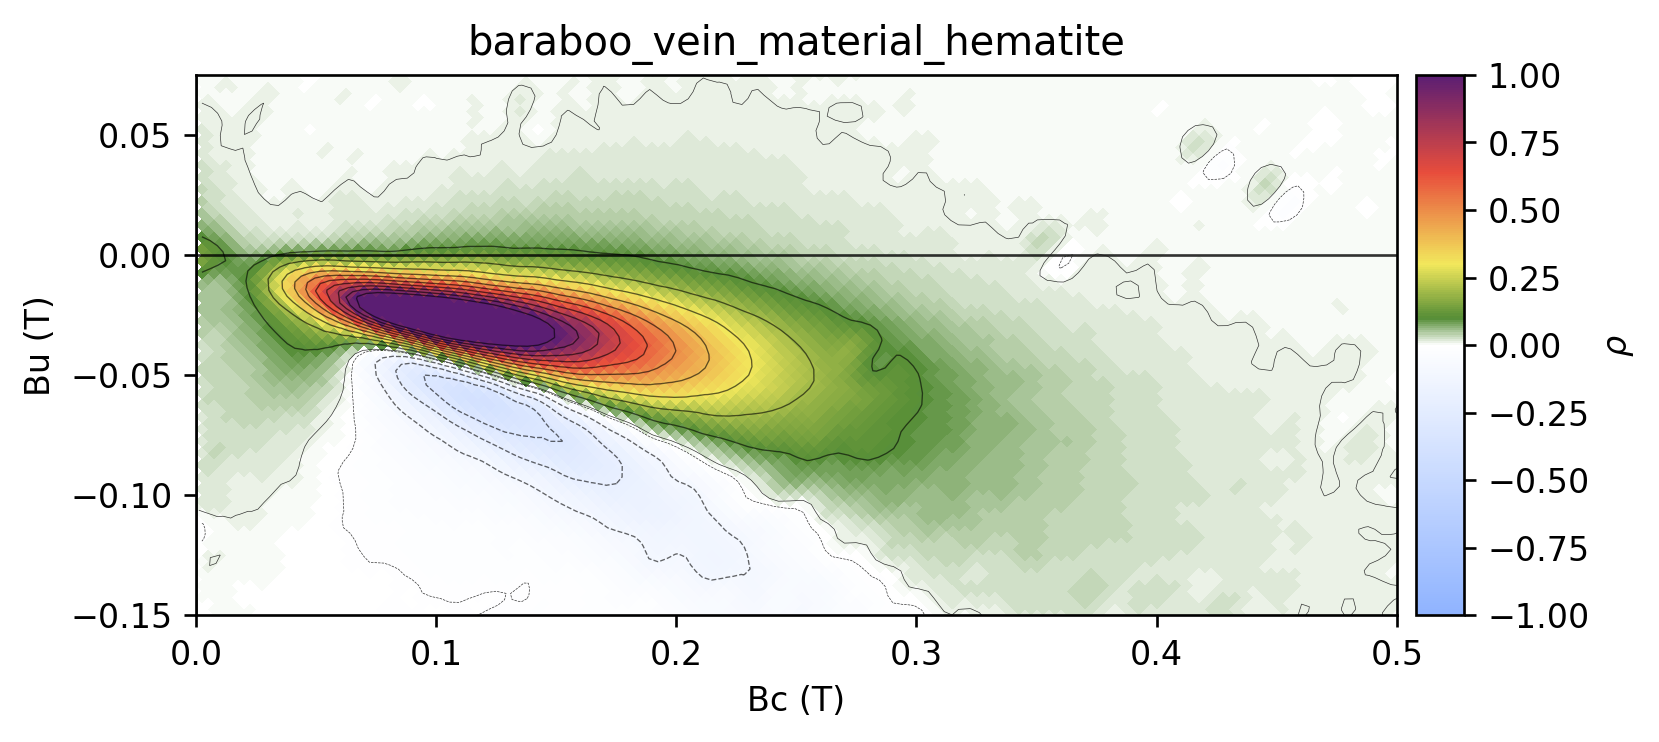

smooth_strength = 1.0: span 25 mT, peak at Bc = 107.5 mT, Bu = -27.5 mT


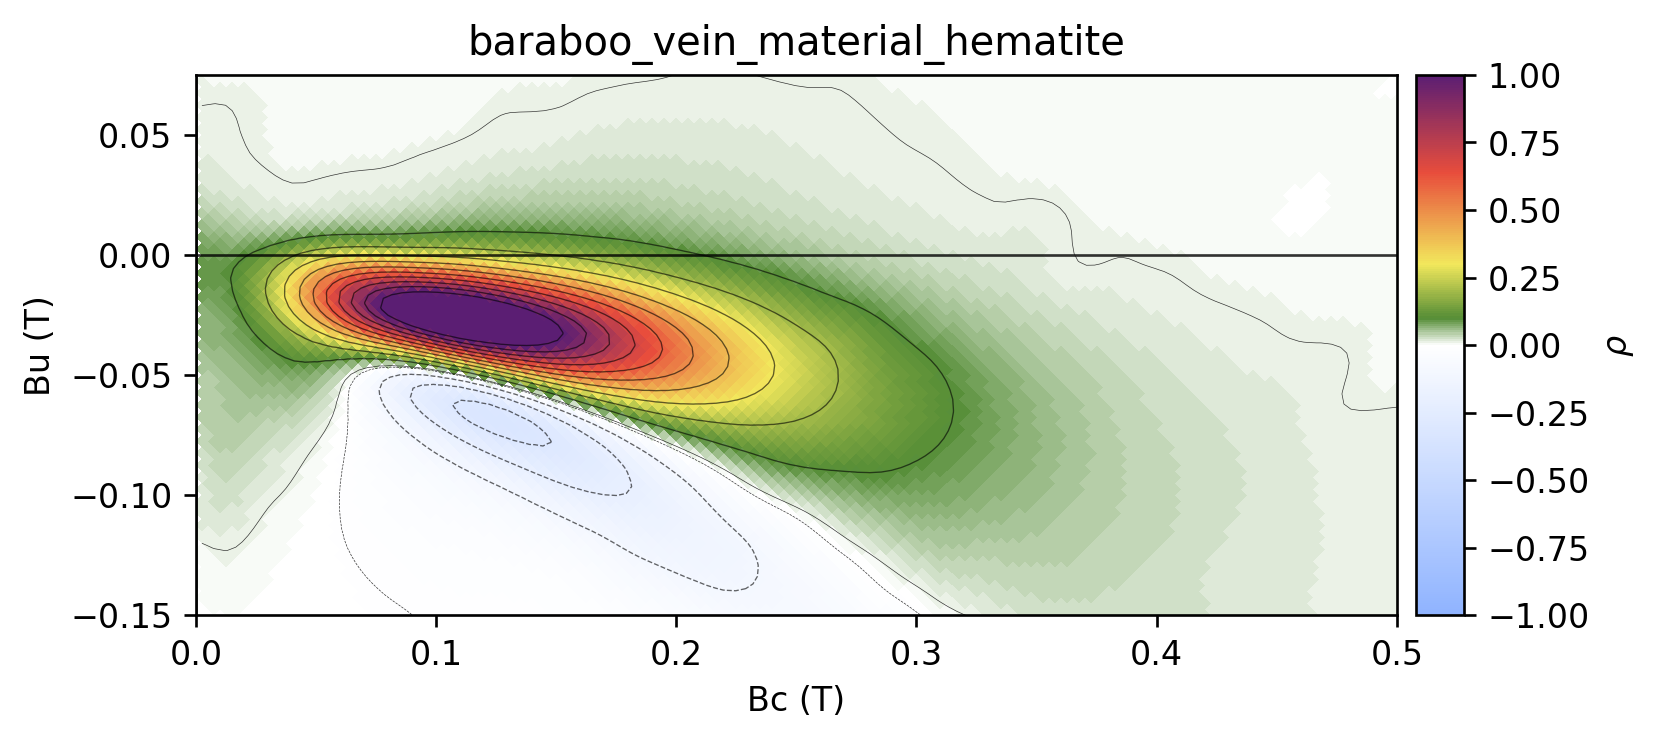

smooth_strength = 2.0: span 50 mT, peak at Bc = 110.0 mT, Bu = -25.0 mT


In [2]:
raw_file = '../example_data/FORC/baraboo_vein_material_hematite.txt'

for strength in [0.5, 1.0, 2.0]:
    trial = forc.process_forc(
        mode='i', path=raw_file, do_regrid=True, B_step=0.005,
        smooth_strength=strength, Bu_min=-0.15, Bu_max=0.075, Bc_max=0.5,
        color_scale_version=2, plot_hyst=False, verbose=False,
    )
    peak = forc.find_bounded_peak_rho(trial['Ha_vals_used'], trial['Hb_vals_used'],
                                      trial['rho'], Bu_min=-0.15, Bu_max=0.075,
                                      Bc_min=0.0, Bc_max=0.5)
    print(f"smooth_strength = {strength}: "
          f"span {1e3 * trial['loess_params']['span_Ha_T_used']:.0f} mT, "
          f"peak at Bc = {1e3 * peak['bc']:.1f} mT, Bu = {1e3 * peak['bu']:.1f} mT")

The peak position is stable across a factor of four in smoothing, so it is a property
of the sample rather than of the processing. The amplitude and the apparent width are not
stable, so they must be quoted with the span that produced them.

The rest of the notebook explains why that recipe is the right one.

## 2. Why smoothing is not optional

Differentiating twice amplifies noise. If the magnetization is measured with a small
random error, the error on a finite-difference second derivative scales roughly as the
measurement noise divided by the square of the field step, so on a 5 mT grid a
noise level of one part in 10⁴ becomes a large fractional error on $\rho$.

Local regression sidesteps this by fitting a smooth surface to many neighbouring points
and differentiating the fit rather than the data. The price is bias: a fitted quadratic
cannot follow structure narrower than its own neighbourhood, so real features that are
narrower than the window are broadened and attenuated. Every FORC diagram sits somewhere
on that bias–variance trade-off, and the smoothing level is what selects the position.

## 3. The local-regression neighbourhood

At each grid node `pmagpy.forc` collects the measurements inside an ellipse in index
space, weights them by the LOESS tricube function of scaled distance,

$$w(u) = (1 - u^3)^3, \qquad u = \sqrt{(\Delta j / r_x)^2 + (\Delta i / r_y)^2} \le 1,$$

and fits a quadratic surface in the two field coordinates. The mixed term of that fit is
the FORC distribution. The semi-axes $r_x$ and $r_y$ are the spans `span_Hb_T` and
`span_Ha_T` divided by the grid steps.

The tricube weight falls smoothly to zero at the edge of the neighbourhood, so a point
does not enter or leave the fit abruptly as the window moves — the resulting distribution
is continuous.

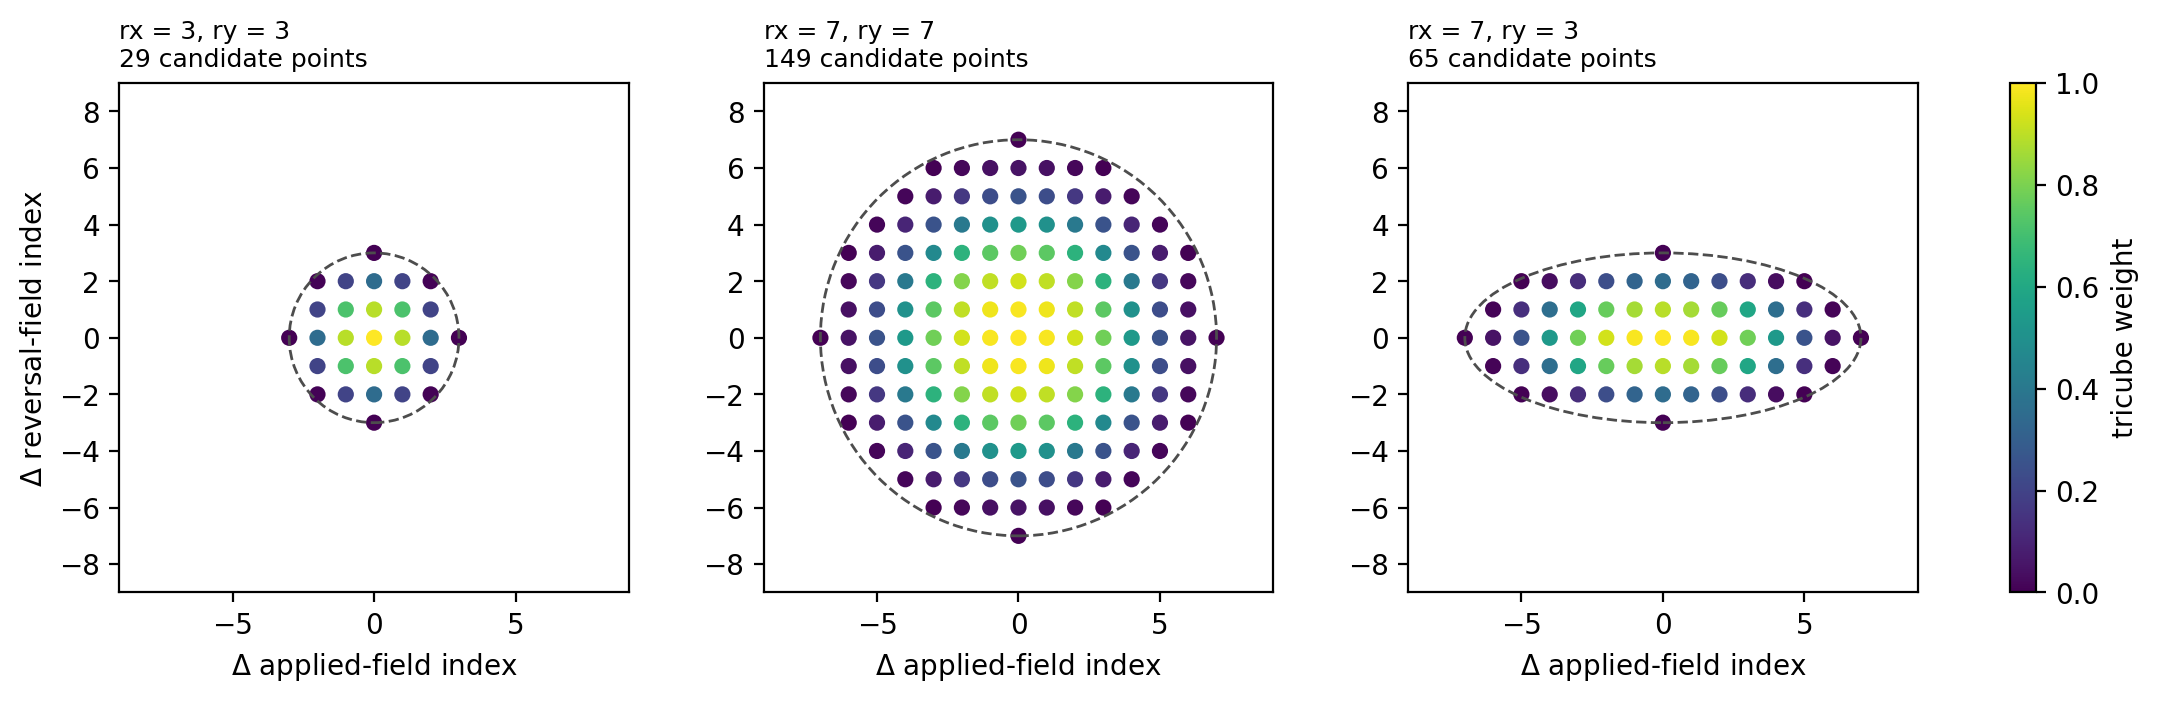

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), constrained_layout=True)

for ax, (rx, ry) in zip(axes, [(3, 3), (7, 7), (7, 3)]):
    offsets = forc.loess_offsets(rx, ry)
    di, dj, u = offsets[:, 0], offsets[:, 1], offsets[:, 2]
    weights = (1.0 - u ** 3) ** 3
    sc = ax.scatter(dj, di, c=weights, s=34, cmap='viridis', vmin=0, vmax=1,
                    edgecolors='none')
    ax.add_patch(Ellipse((0, 0), 2 * rx, 2 * ry, fill=False, ec='0.3', lw=1.0, ls='--'))
    ax.set_aspect('equal')
    ax.set_xlim(-9, 9)
    ax.set_ylim(-9, 9)
    ax.set_xlabel(r'$\Delta$ applied-field index')
    ax.set_title(f'rx = {rx}, ry = {ry}\n{offsets.shape[0]} candidate points',
                 fontsize=9, loc='left')

axes[0].set_ylabel(r'$\Delta$ reversal-field index')
fig.colorbar(sc, ax=axes, label='tricube weight', fraction=0.03)
plt.show()

The right-hand panel shows an anisotropic neighbourhood. That is what happens when
the reversal-field increment differs from the applied-field step: the spans are set in
tesla, so the ellipse is elongated in index units along whichever axis is finely sampled.

### Only part of the neighbourhood is usable

Two things remove candidate points. The half-plane $H_b < H_a$ is not physical and holds
no data, so nodes near the $B_c = 0$ diagonal are fitted from a one-sided window. Nodes
near the edge of the measured region lose points the same way. This is worth seeing
explicitly, because it is where FORC distributions are least well constrained.

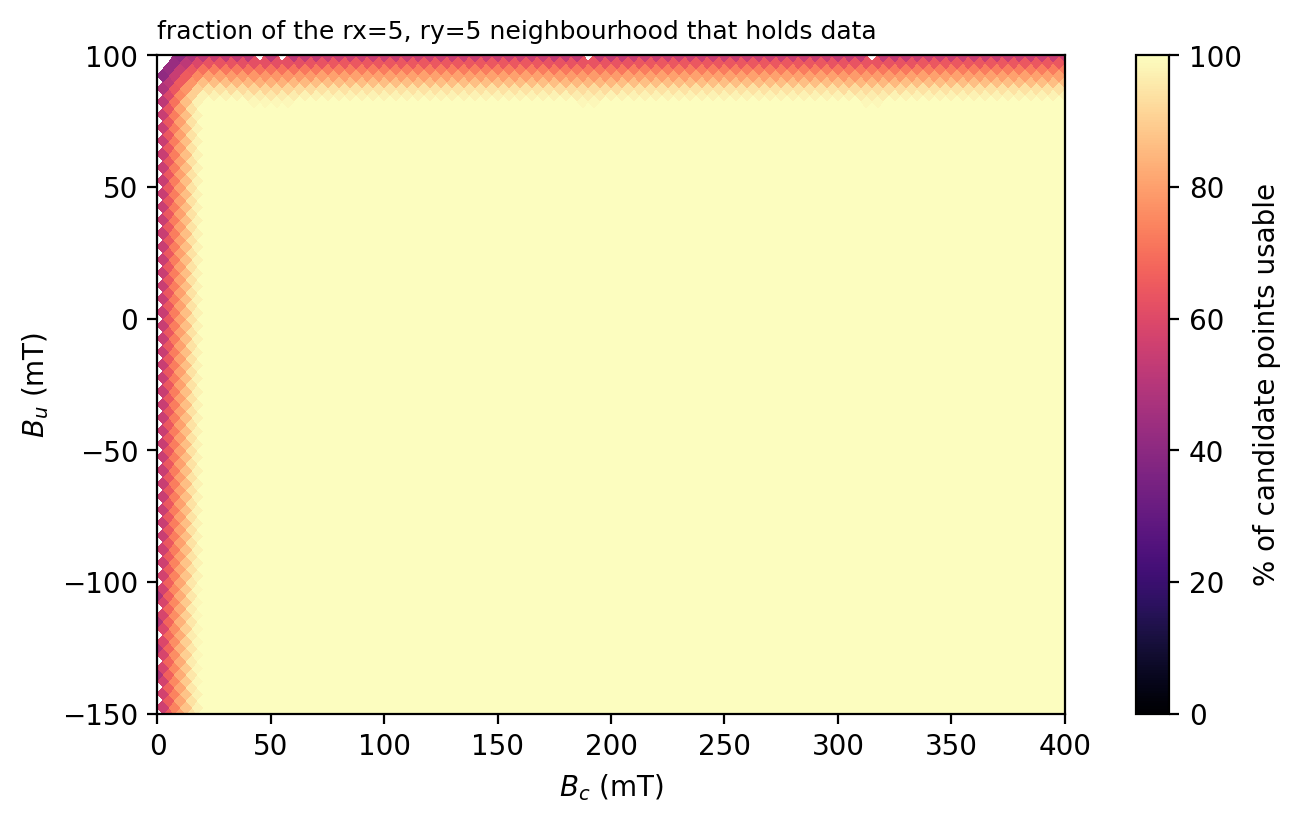

minimum points required (min_pts) : 34 of 81 candidates
nodes fitted from a full window   : 49%


In [4]:
segments, _ = forc.phase1_prepare_segments_dual(raw_file, export_magic=False,
                                                verbose=False)
curves = [s for s in segments if s.kind == 'forc']
curves = forc.regrid_forcs_in_hysteresis_space(curves, B_step=0.005, verbose=False)
Ha_vals, Hb_vals, M_grid, dHb, dHa = forc.build_forc_grid(curves, verbose=False)

guess = forc.guess_loess_params(Ha_vals, Hb_vals, M_grid)
rx, ry = guess['rx'], guess['ry']
offsets = forc.loess_offsets(rx, ry)
di = offsets[:, 0].astype(int)
dj = offsets[:, 1].astype(int)

physical = Hb_vals[None, :] >= Ha_vals[:, None]
valid = np.isfinite(M_grid) & physical

usable = np.full(M_grid.shape, np.nan)
rows, cols = np.nonzero(valid)
for i, j in zip(rows, cols):
    ii, jj = i + di, j + dj
    inside = (ii >= 0) & (ii < valid.shape[0]) & (jj >= 0) & (jj < valid.shape[1])
    usable[i, j] = np.count_nonzero(valid[ii[inside], jj[inside]])

Bc = 0.5 * (Hb_vals[None, :] - Ha_vals[:, None])
Bu = 0.5 * (Hb_vals[None, :] + Ha_vals[:, None])

fig, ax = plt.subplots(figsize=(6.4, 4.0), constrained_layout=True)
mesh = ax.pcolormesh(1e3 * Bc, 1e3 * Bu, 100 * usable / offsets.shape[0],
                     cmap='magma', vmin=0, vmax=100, shading='auto')
ax.set_xlim(0, 400)
ax.set_ylim(-150, 100)
ax.set_xlabel(r'$B_c$ (mT)')
ax.set_ylabel(r'$B_u$ (mT)')
ax.set_title(f'fraction of the rx={rx}, ry={ry} neighbourhood that holds data',
             fontsize=9, loc='left')
fig.colorbar(mesh, ax=ax, label='% of candidate points usable')
plt.show()

print(f"minimum points required (min_pts) : {guess['min_pts_suggested']} "
      f"of {offsets.shape[0]} candidates")
print(f"nodes fitted from a full window   : "
      f"{100 * np.nanmean(usable == offsets.shape[0]):.0f}%")

The dark band along $B_c = 0$ is the diagonal truncation: near the zero-coercivity
axis, roughly half the neighbourhood lies in the unphysical half-plane. Values there are
estimated from a one-sided fit and should be treated with more caution than the interior.
`edge_mask_bc_bins` can mask a chosen number of bins along that axis if you would rather
not show them. VARIFORC handles the same problem with an explicit trim factor on the
lower diagonal limit.

## 4. How the window size is chosen

`guess_loess_params` does not look at the data values at all — it works from the geometry
of the measurement. It grows the ellipse until the *expected* number of usable points,
the candidate count times the fill fraction, reaches a target that keeps the six-parameter
quadratic comfortably over-determined.

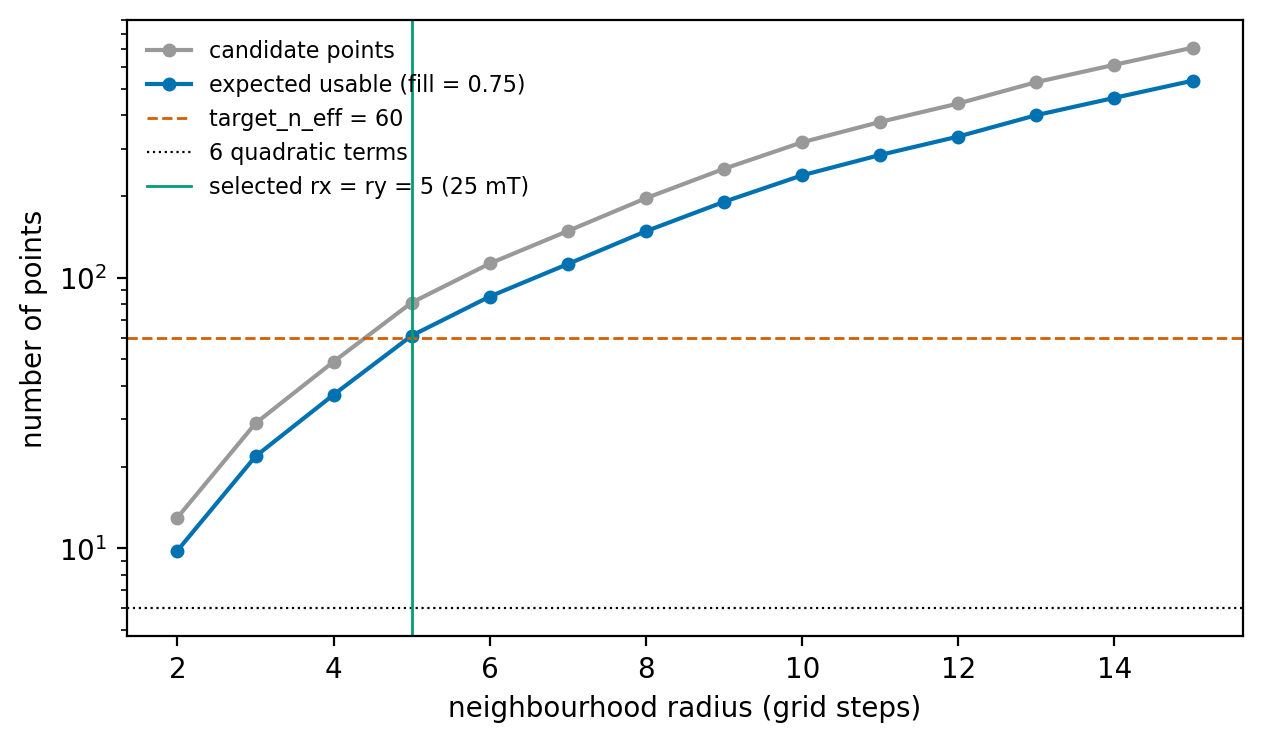

grid steps      : dHa = 5.0 mT, dHb = 5.0 mT
fill fraction   : 0.755 of the physical half-plane
selected spans  : 25 mT x 25 mT
min_pts         : 34


In [5]:
fill = guess['fill_fraction']
radii = np.arange(2, 16)
n_candidate = np.array([forc.loess_offsets(r, r).shape[0] for r in radii])
n_effective = fill * n_candidate

fig, ax = plt.subplots(figsize=(6.2, 3.6), constrained_layout=True)
ax.plot(radii, n_candidate, 'o-', ms=4, color='0.6', label='candidate points')
ax.plot(radii, n_effective, 'o-', ms=4, color='#0072B2',
        label=f'expected usable (fill = {fill:.2f})')
ax.axhline(60, color='#D55E00', lw=1.0, ls='--', label='target_n_eff = 60')
ax.axhline(6, color='k', lw=0.8, ls=':', label='6 quadratic terms')
ax.axvline(rx, color='#009E73', lw=1.0,
           label=f'selected rx = ry = {rx} ({1e3 * guess["span_Ha_T"]:.0f} mT)')
ax.set_yscale('log')
ax.set_xlabel('neighbourhood radius (grid steps)')
ax.set_ylabel('number of points')
ax.legend(fontsize=8, frameon=False)
plt.show()

print(f"grid steps      : dHa = {1e3 * guess['dHa']:.1f} mT, "
      f"dHb = {1e3 * guess['dHb']:.1f} mT")
print(f"fill fraction   : {fill:.3f} of the physical half-plane")
print(f"selected spans  : {1e3 * guess['span_Ha_T']:.0f} mT x "
      f"{1e3 * guess['span_Hb_T']:.0f} mT")
print(f"min_pts         : {guess['min_pts_suggested']}")

The fill fraction is measured over the physical half-plane $H_b \geq H_a$ only.
Counting the structurally empty triangle would make the data look sparser than it is and
would inflate the window.

`smooth_strength` multiplies the selected spans, and `min_pts_strength` the minimum-point
threshold. The automated value is a defensible starting point, not an answer.

## 5. What over- and under-smoothing do to a known feature

The clearest way to see the trade-off is on a synthetic distribution whose answer is known
exactly. We build a magnetization surface from a separable Preisach assemblage — a
narrow ridge at $B_u = 0$ of known width — add realistic measurement noise, and ask how
well each smoothing level recovers the ridge.

In [6]:
from scipy.stats import norm

Ms = 1.0e-5
BC0 = 0.040               # ridge centred at 40 mT coercivity
SIGMA_BU = 0.004          # 4 mT ridge half-width in Bu: a narrow feature
SIGMA_BC = 0.020
NOISE = 2.0e-8            # 20 nAm2, a realistic VSM noise floor (SNR ~500)

step = 0.002
Ha_s = np.arange(-0.14, 0.10 + step / 2, step)
Hb_s = np.arange(-0.14, 0.10 + step / 2, step)
A, B = np.meshgrid(Ha_s, Hb_s, indexing='ij')

alpha0, beta0 = BC0, -BC0
p_up = (norm.cdf(A, beta0, SIGMA_BU) +
        (1 - norm.cdf(A, beta0, SIGMA_BU)) * norm.cdf(B, alpha0, SIGMA_BU))
M_clean = Ms * (2 * p_up - 1)

rng = np.random.default_rng(0)
M_noisy = M_clean + NOISE * rng.standard_normal(M_clean.shape)
M_noisy[B < A] = np.nan

rho_true = Ms * norm.pdf(B, alpha0, SIGMA_BU) * norm.pdf(A, beta0, SIGMA_BU)
rho_true[B < A] = np.nan

Bc_s = 0.5 * (B - A)
Bu_s = 0.5 * (B + A)
print(f"true ridge: peak Bc = {1e3 * BC0:.0f} mT, "
      f"Bu half-width = {1e3 * SIGMA_BU:.0f} mT, "
      f"FWHM in Bu = {1e3 * 2 * np.sqrt(2 * np.log(2)) * SIGMA_BU / np.sqrt(2):.1f} mT")

true ridge: peak Bc = 40 mT, Bu half-width = 4 mT, FWHM in Bu = 6.7 mT


In [7]:
spans = np.array([0.003, 0.004, 0.006, 0.008, 0.012, 0.016, 0.024, 0.032, 0.048])
rows = []

for span in spans:
    rho_s = forc.loess_rho_from_grid_fast(Ha_s, Hb_s, M_noisy,
                                          span_Ha_T=span, span_Hb_T=span, min_pts=8)
    k = np.nanargmax(rho_s)
    cut = forc.slice_profile_smoothed(Ha_s, Hb_s, rho_s, mode='Bc',
                                      target=Bc_s.ravel()[k], x_min=-0.05, x_max=0.05,
                                      bin_width=0.0005, smooth_sigma_bins=0)
    # noise read from a region the ridge does not reach; total error against truth
    background = (Bc_s > 0.07) & (np.abs(Bu_s) < 0.04) & np.isfinite(rho_s)
    everywhere = np.isfinite(rho_s) & np.isfinite(rho_true)
    rows.append(dict(span=span,
                     amplitude=np.nanmax(rho_s) / np.nanmax(rho_true),
                     fwhm=1e3 * cut['peak']['fwhm'],
                     noise=np.nanstd(rho_s[background]) / np.nanmax(rho_true),
                     total=np.sqrt(np.mean((rho_s[everywhere] -
                                            rho_true[everywhere]) ** 2))
                     / np.nanmax(rho_true)))

true_fwhm = 1e3 * 2 * np.sqrt(2 * np.log(2)) * SIGMA_BU / np.sqrt(2)
print(f"{'span (mT)':>10} {'peak / true':>12} {'Bu FWHM (mT)':>14} "
      f"{'background noise':>18} {'total RMS error':>17}")
for r in rows:
    print(f"{1e3 * r['span']:10.0f} {r['amplitude']:12.2f} {r['fwhm']:14.1f} "
          f"{r['noise']:18.2%} {r['total']:17.2%}")
print(f"{'true':>10} {1.0:12.2f} {true_fwhm:14.1f} {0.0:18.2%} {0.0:17.2%}")
best = min(rows, key=lambda r: r['total'])
print(f"\ntotal error is minimized at a span of {1e3 * best['span']:.0f} mT, "
      f"against a true ridge width of {1e3 * 2 * SIGMA_BU:.0f} mT")

 span (mT)  peak / true   Bu FWHM (mT)   background noise   total RMS error
         3         0.92            7.0              1.26%             1.42%
         4         0.92            7.0              1.26%             1.42%
         6         0.85            7.3              0.51%             0.75%
         8         0.75            7.6              0.23%             0.84%
        12         0.57            8.9              0.07%             1.44%
        16         0.42           10.6              0.06%             2.02%
        24         0.24           14.3              0.19%             2.84%
        32         0.15           18.3              0.25%             3.31%
        48         0.07           26.8              0.22%             3.73%
      true         1.00            6.7              0.00%             0.00%

total error is minimized at a span of 6 mT, against a true ridge width of 8 mT


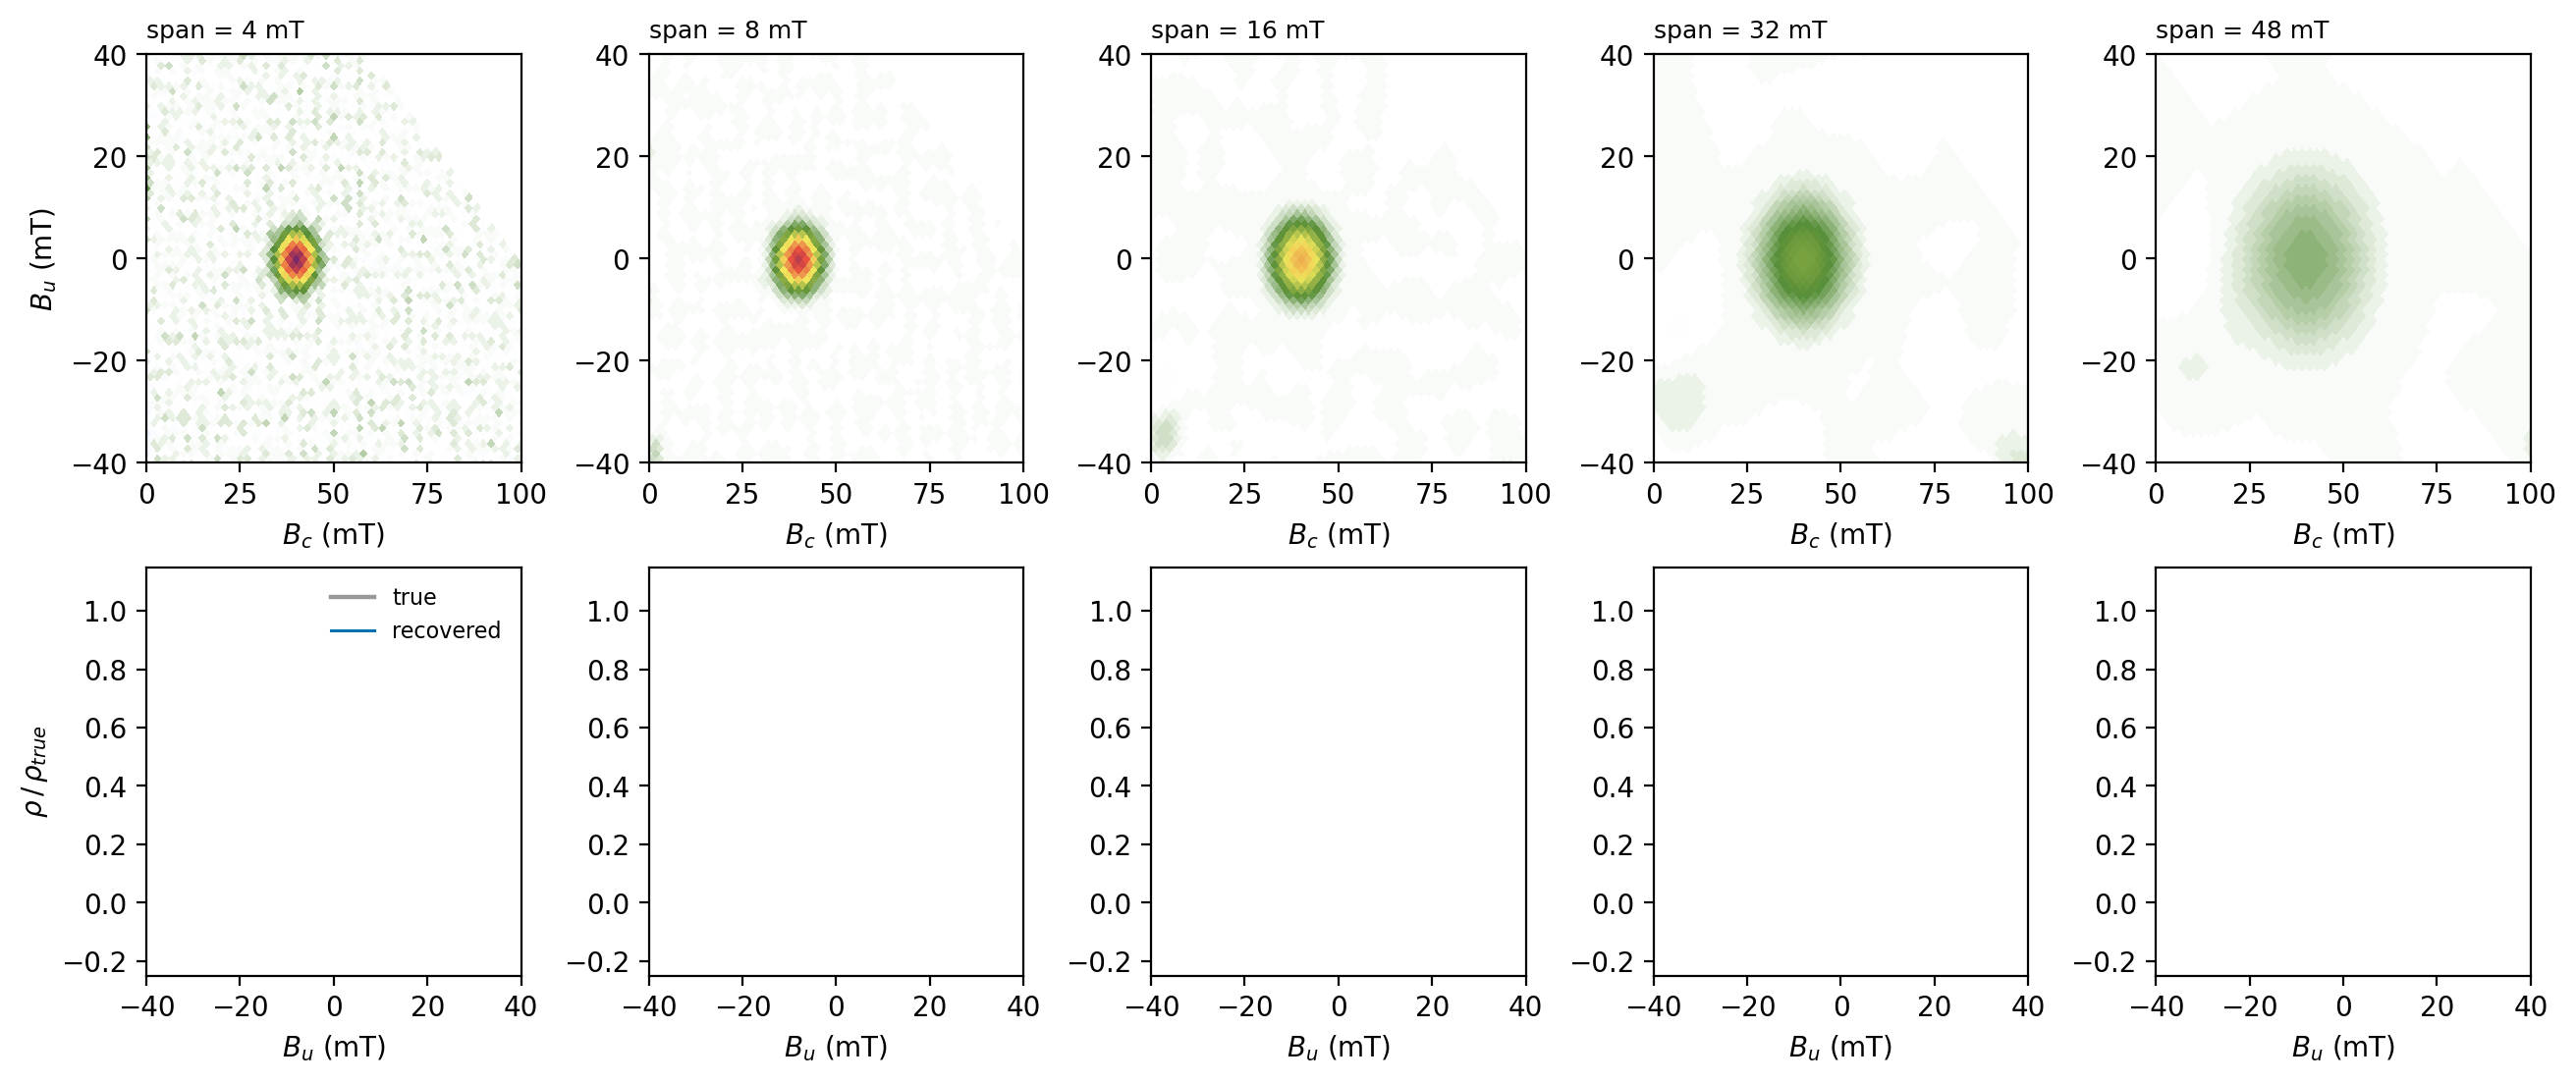

In [8]:
shown = np.array([0.004, 0.008, 0.016, 0.032, 0.048])
fig, axes = plt.subplots(2, len(shown), figsize=(13, 5.4), constrained_layout=True,
                         sharex='row')

for col, span in enumerate(shown):
    rho_s = forc.loess_rho_from_grid_fast(Ha_s, Hb_s, M_noisy,
                                          span_Ha_T=span, span_Hb_T=span, min_pts=8)
    vmax = np.nanmax(rho_true)

    ax = axes[0, col]
    ax.pcolormesh(1e3 * Bc_s, 1e3 * Bu_s, rho_s / vmax, cmap=forc.get_forc_cmap(2),
                  vmin=-1, vmax=1, shading='auto')
    ax.set_xlim(0, 100)
    ax.set_ylim(-40, 40)
    ax.set_title(f'span = {1e3 * span:.0f} mT', fontsize=9, loc='left')
    ax.set_xlabel(r'$B_c$ (mT)')

    ax = axes[1, col]
    k = np.nanargmax(rho_s)
    cut = forc.slice_profile_smoothed(Ha_s, Hb_s, rho_s, mode='Bc',
                                      target=Bc_s.ravel()[k], x_min=-0.05, x_max=0.05,
                                      bin_width=0.0005, smooth_sigma_bins=0)
    truth = forc.slice_profile_smoothed(Ha_s, Hb_s, rho_true, mode='Bc', target=BC0,
                                        x_min=-0.05, x_max=0.05, bin_width=0.0005,
                                        smooth_sigma_bins=0)
    ax.plot(1e3 * truth['x'], truth['y'] / vmax, color='0.6', lw=1.6, label='true')
    ax.plot(1e3 * cut['x'], cut['y'] / vmax, color='#0072B2', lw=1.1, label='recovered')
    ax.set_ylim(-0.25, 1.15)
    ax.set_xlim(-40, 40)
    ax.set_xlabel(r'$B_u$ (mT)')
    if col == 0:
        ax.legend(fontsize=8, frameon=False)

axes[0, 0].set_ylabel(r'$B_u$ (mT)')
axes[1, 0].set_ylabel(r'$\rho\,/\,\rho_{true}$')
plt.show()

The pattern is the one the FORC literature describes for the central ridge of
noninteracting single-domain particles. At the smallest span the ridge is in the right
place and the right width, but the background is visibly noisy. As the span grows the
background cleans up while the ridge broadens and its amplitude falls: at four times the
ridge width the recovered peak is a fraction of the true value and the measured width is
set by the smoothing window rather than by the sample.

That attenuation is the specific reason oversmoothing blurs the distinction between a
noninteracting assemblage and a weakly interacting one — the diagnostic is the *narrowness*
of the ridge in $B_u$, and smoothing destroys exactly that.

## 6. Choosing a level from the residuals

FORCinel selects the smoothing factor from the residuals between the measured and smoothed
magnetization surfaces, increasing the smoothing until the residuals indicate that signal
rather than noise is being removed ([Harrison and Feinberg, 2008](https://doi.org/10.1029/2008GC001987)).
`loess_rho_from_grid_fast(..., return_fit=True)` returns the fitted surface, so the same
diagnostic can be computed here.

While the window is small enough that the quadratic can follow the true surface, the
residual measures only measurement noise and is flat with respect to the span. Once the
window exceeds the scale of real structure, the fit starts removing signal and the
residual climbs. The departure from the noise floor is the criterion.

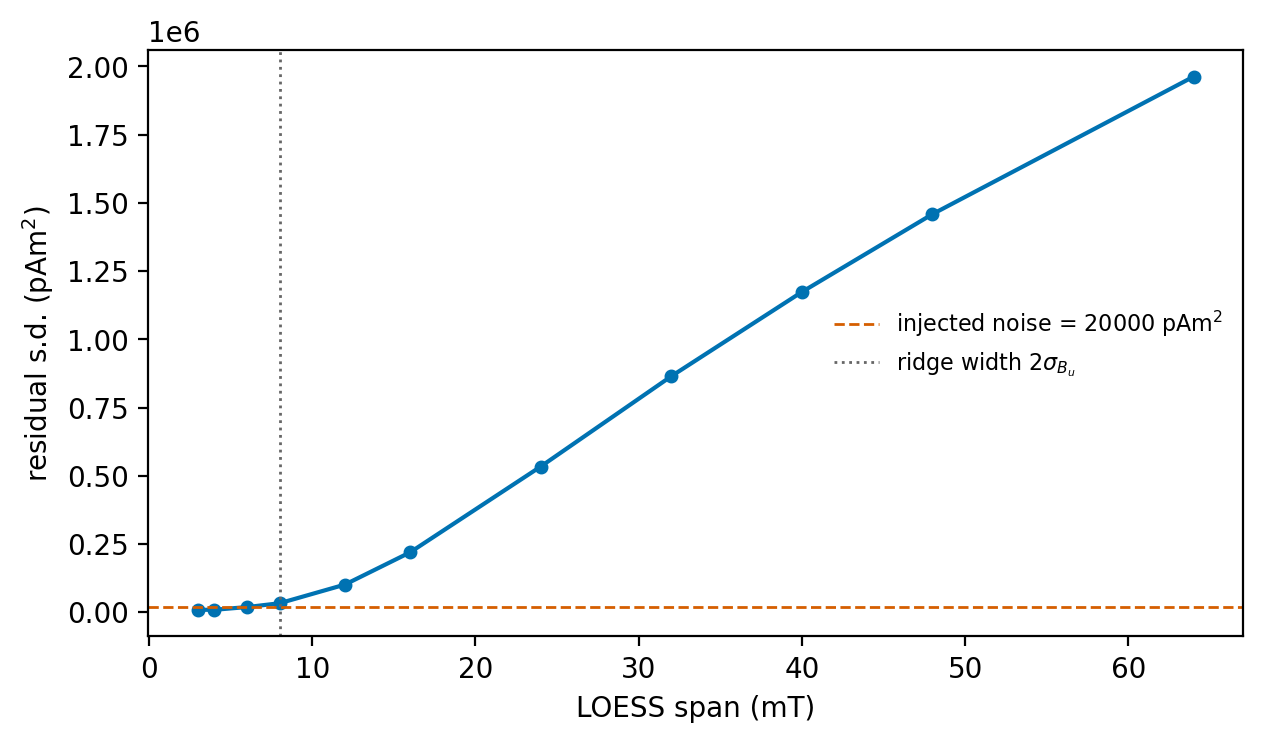

residual crosses the noise floor at a span of about 8 mT, against a true ridge width of 8 mT


In [9]:
trial_spans = np.array([0.003, 0.004, 0.006, 0.008, 0.012, 0.016, 0.024, 0.032,
                        0.040, 0.048, 0.064])
residuals = []
for span in trial_spans:
    _, M_fit = forc.loess_rho_from_grid_fast(Ha_s, Hb_s, M_noisy, span_Ha_T=span,
                                             span_Hb_T=span, min_pts=8, return_fit=True)
    ok = np.isfinite(M_fit) & np.isfinite(M_noisy)
    residuals.append(np.std(M_noisy[ok] - M_fit[ok]))
residuals = np.array(residuals)

fig, ax = plt.subplots(figsize=(6.2, 3.6), constrained_layout=True)
ax.plot(1e3 * trial_spans, 1e12 * residuals, 'o-', ms=4, color='#0072B2')
ax.axhline(1e12 * NOISE, color='#D55E00', lw=1.0, ls='--',
           label=f'injected noise = {1e12 * NOISE:.0f} pAm$^2$')
ax.axvline(1e3 * 2 * SIGMA_BU, color='0.4', lw=1.0, ls=':',
           label=r'ridge width $2\sigma_{B_u}$')
ax.set_xlabel('LOESS span (mT)')
ax.set_ylabel(r'residual s.d. (pAm$^2$)')
ax.legend(fontsize=8, frameon=False)
plt.show()

crossing = trial_spans[np.argmax(residuals > NOISE)]
print(f"residual crosses the noise floor at a span of about {1e3 * crossing:.0f} mT, "
      f"against a true ridge width of {1e3 * 2 * SIGMA_BU:.0f} mT")

## 7. On real data

The hematite example has no known answer, but the same trade-off is visible, and the
residual diagnostic behaves the same way. Here the residual is dominated by real
structure at much smaller spans than in the synthetic case, because the measured surface
has curvature on every scale.

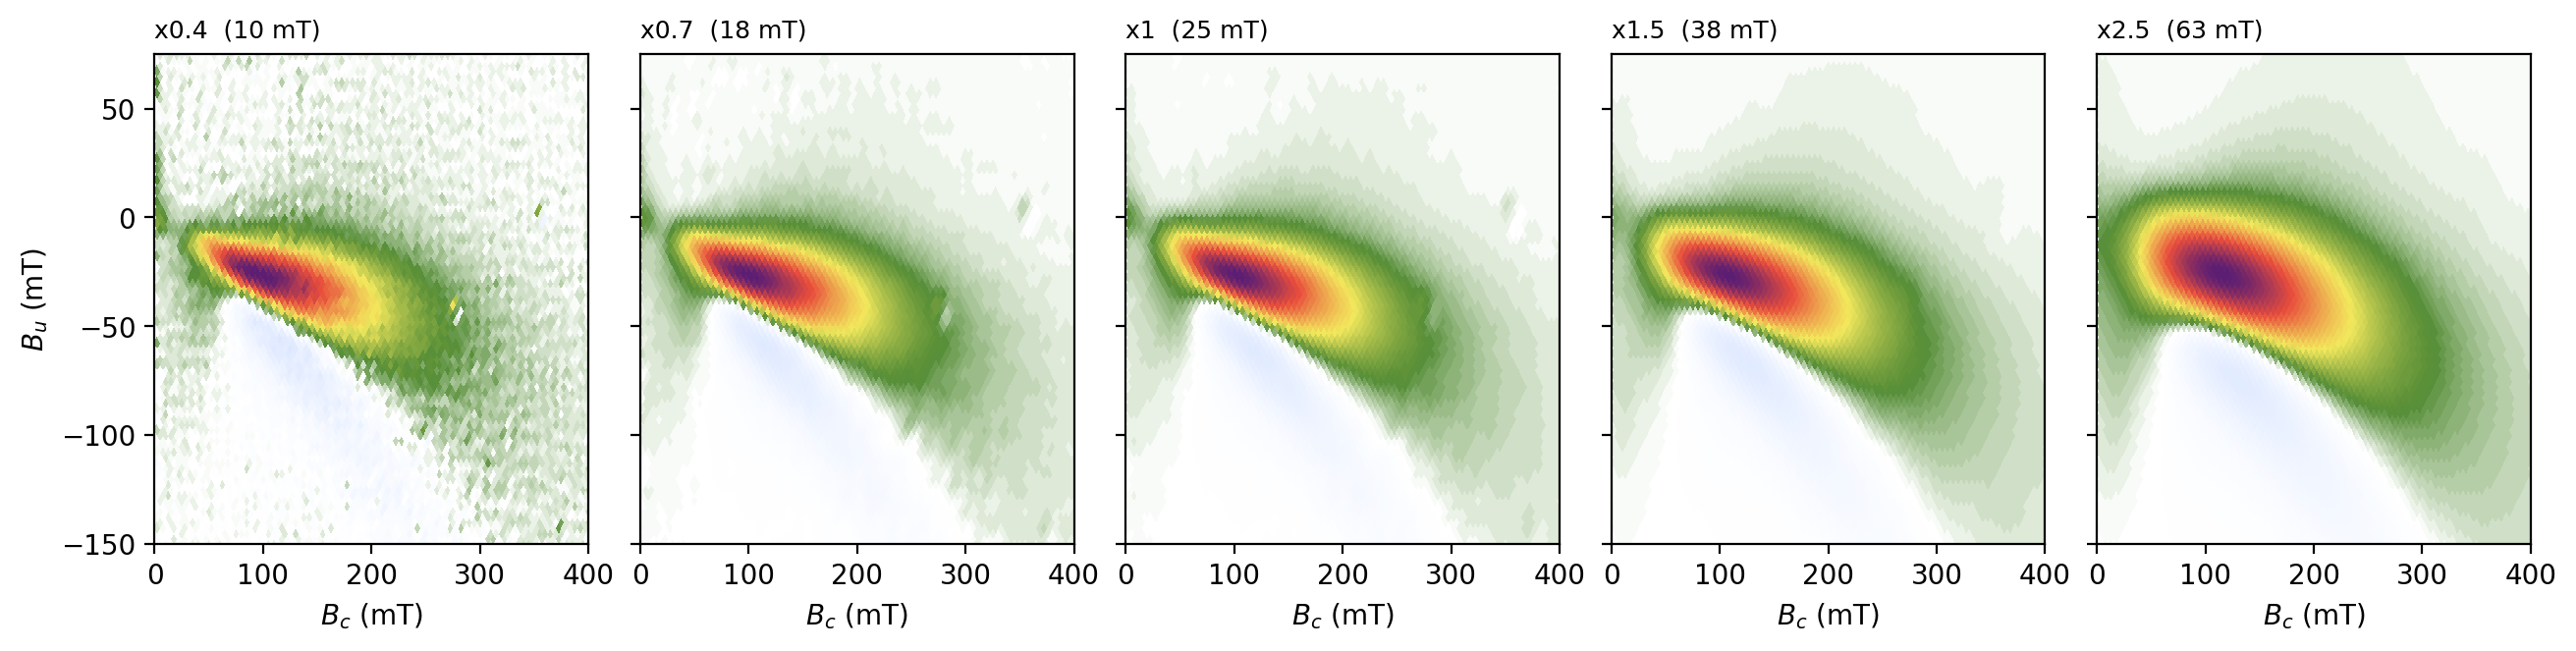

 strength    span   peak Bc   peak Bu   Bu FWHM   residual
             (mT)      (mT)      (mT)      (mT)     (pAm2)
      0.4      10      95.0     -25.0      20.8     506.45
      0.7      18     102.5     -27.5      23.0    4179.59
        1      25     107.5     -27.5      24.3    4698.67
      1.5      38     105.0     -25.0      27.7    6296.76
      2.5      63     115.0     -25.0      37.5   12466.86


In [10]:
strengths = np.array([0.4, 0.7, 1.0, 1.5, 2.5])
fig, axes = plt.subplots(1, len(strengths), figsize=(13, 3.2),
                         constrained_layout=True, sharey=True)

summary = []
for ax, strength in zip(axes, strengths):
    span = strength * guess['span_Ha_T']
    rho_r, M_fit = forc.loess_rho_from_grid_fast(
        Ha_vals, Hb_vals, M_grid, span_Ha_T=span, span_Hb_T=span,
        min_pts=max(6, int(strength ** 2 * guess['min_pts_suggested'])),
        return_fit=True)

    vmax = forc.rho_window_vmax(Ha_vals, Hb_vals, rho_r, pct=100, Bu_min=-0.15,
                                 Bu_max=0.075, Bc_min=0.0, Bc_max=0.5)
    ax.pcolormesh(1e3 * Bc, 1e3 * Bu, rho_r / vmax, cmap=forc.get_forc_cmap(2),
                  vmin=-1, vmax=1, shading='auto')
    ax.set_xlim(0, 400)
    ax.set_ylim(-150, 75)
    ax.set_xlabel(r'$B_c$ (mT)')
    ax.set_title(f'x{strength:g}  ({1e3 * span:.0f} mT)', fontsize=9, loc='left')

    peak = forc.find_bounded_peak_rho(Ha_vals, Hb_vals, rho_r, Bu_min=-0.15,
                                      Bu_max=0.075, Bc_min=0.0, Bc_max=0.5)
    cut = forc.slice_profile_smoothed(Ha_vals, Hb_vals, rho_r, mode='Bc',
                                      target=peak['bc'], x_min=-0.15, x_max=0.075,
                                      bin_width=0.001, smooth_sigma_bins=2.5)
    ok = np.isfinite(M_fit) & np.isfinite(M_grid)
    summary.append((strength, 1e3 * span, 1e3 * peak['bc'], 1e3 * peak['bu'],
                    1e3 * cut['peak']['fwhm'],
                    1e12 * np.std(M_grid[ok] - M_fit[ok])))

axes[0].set_ylabel(r'$B_u$ (mT)')
plt.show()

print(f"{'strength':>9} {'span':>7} {'peak Bc':>9} {'peak Bu':>9} {'Bu FWHM':>9} "
      f"{'residual':>10}")
print(f"{'':>9} {'(mT)':>7} {'(mT)':>9} {'(mT)':>9} {'(mT)':>9} {'(pAm2)':>10}")
for row in summary:
    print(f"{row[0]:9g} {row[1]:7.0f} {row[2]:9.1f} {row[3]:9.1f} {row[4]:9.1f} "
          f"{row[5]:10.2f}")

The peak position is stable across this range, which is reassuring: the location of
the hematite feature is not an artefact of the smoothing. Its *width* is not stable, so a
reported FWHM is meaningful only alongside the smoothing level that produced it. This is
why `out['loess_params']` records the spans actually used.

## 8. What spatially variable smoothing would add

Everything above uses one window everywhere. That is a compromise whenever a diagram
contains features on different scales at once — which is the normal case: a narrow ridge
near $B_u = 0$ sitting on a broad, low-amplitude background.

The compromise can be quantified. Take the synthetic case and ask, separately for the
ridge and for the background, which span gives the best result in that region.


In [11]:
ridge_region = (np.abs(Bu_s) < 0.010) & (np.abs(Bc_s - BC0) < 0.020)
background_region = (Bc_s > 0.07) & (np.abs(Bu_s) < 0.04)

print(f"{'span (mT)':>10} {'ridge error':>13} {'background noise':>18}")
ridge_err, back_err = [], []
for span in spans:
    rho_s = forc.loess_rho_from_grid_fast(Ha_s, Hb_s, M_noisy, span_Ha_T=span,
                                          span_Hb_T=span, min_pts=8)
    ok_r = ridge_region & np.isfinite(rho_s) & np.isfinite(rho_true)
    ok_b = background_region & np.isfinite(rho_s)
    r = np.sqrt(np.mean((rho_s[ok_r] - rho_true[ok_r]) ** 2)) / np.nanmax(rho_true)
    b = np.std(rho_s[ok_b]) / np.nanmax(rho_true)
    ridge_err.append(r)
    back_err.append(b)
    print(f"{1e3 * span:10.0f} {r:13.1%} {b:18.2%}")

best_ridge = spans[int(np.argmin(ridge_err))]
best_back = spans[int(np.argmin(back_err))]
print(f"\nbest for the ridge      : {1e3 * best_ridge:.0f} mT")
print(f"best for the background : {1e3 * best_back:.0f} mT")

 span (mT)   ridge error   background noise
         3          1.6%              1.26%
         4          1.6%              1.26%
         6          2.0%              0.51%
         8          3.3%              0.23%


        12          6.0%              0.07%


        16          8.5%              0.06%


        24         12.1%              0.19%


        32         14.0%              0.25%


        48         15.8%              0.22%

best for the ridge      : 3 mT
best for the background : 16 mT


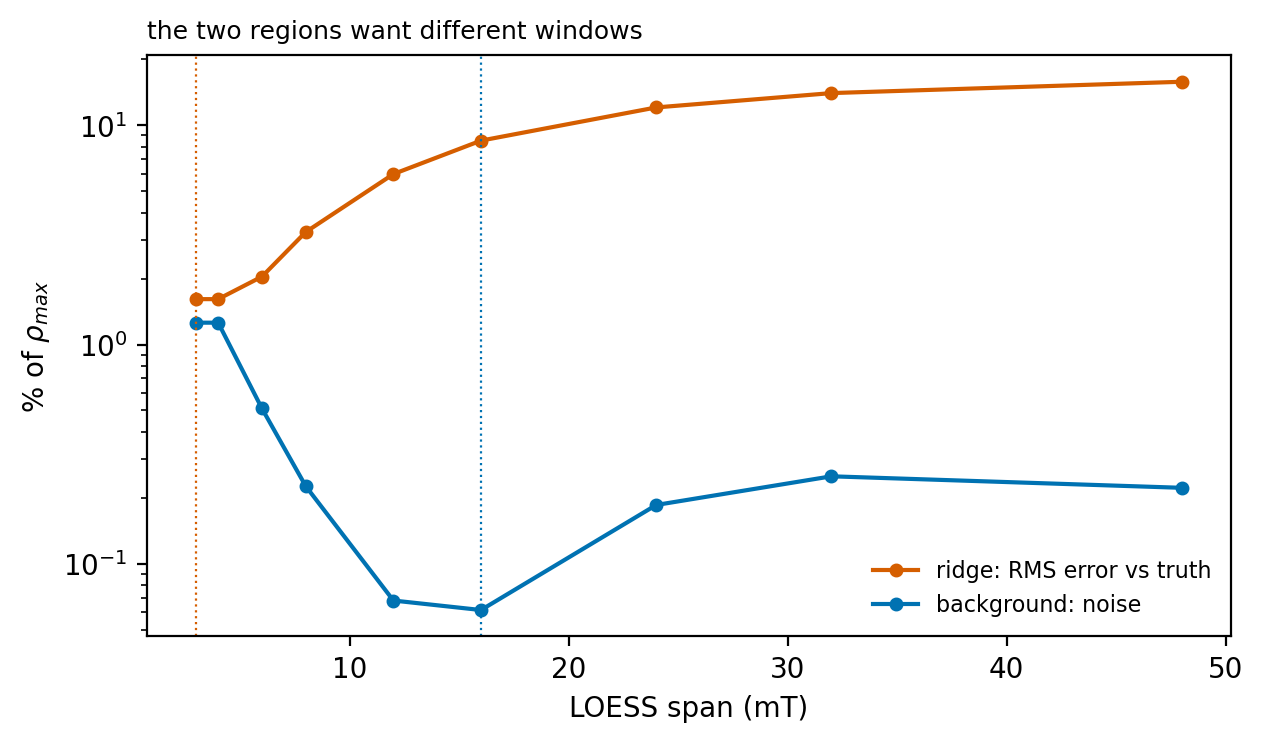

In [12]:
fig, ax = plt.subplots(figsize=(6.2, 3.6), constrained_layout=True)
ax.plot(1e3 * spans, 100 * np.array(ridge_err), 'o-', ms=4, color='#D55E00',
        label='ridge: RMS error vs truth')
ax.plot(1e3 * spans, 100 * np.array(back_err), 'o-', ms=4, color='#0072B2',
        label='background: noise')
ax.axvline(1e3 * best_ridge, color='#D55E00', lw=0.8, ls=':')
ax.axvline(1e3 * best_back, color='#0072B2', lw=0.8, ls=':')
ax.set_yscale('log')
ax.set_xlabel('LOESS span (mT)')
ax.set_ylabel(r'% of $\rho_{max}$')
ax.legend(fontsize=8, frameon=False)
ax.set_title('the two regions want different windows', fontsize=9, loc='left')
plt.show()

The two curves are minimized at different spans, and no single choice is best for
both. Small windows preserve the ridge and leave the background noisy; large windows clean
the background and destroy the ridge.

This is precisely the observation the VARIFORC protocol of
[Egli (2013)](https://doi.org/10.1016/j.gloplacha.2013.08.003) is built on. VARIFORC
applies fine smoothing where narrow features must be preserved and coarser smoothing where
the signal varies slowly, with the smoothing factor allowed to vary along $B_c$, along the
bias axis, and along the diagonals, subject to user-set limits. It also derives an error
matrix and a signal-to-noise significance threshold, so that the parts of the diagram
supported by the data can be distinguished from the parts that are not.

`pmagpy.forc` implements both: variable smoothing is selected with `smoothing='variforc'`,
and the per-cell standard error and signal-to-noise ratio of
[Heslop and Roberts (2012)](https://doi.org/10.1029/2012GC004115) with
`estimate_uncertainty=True`. [FORC_variforc.ipynb](./FORC_variforc.ipynb) applies them to
a sample with a central ridge, where the trade-off shown above is at its sharpest. The
practical recommendation is unchanged whichever estimator is used: compute the
distribution at several smoothing levels, check which features persist and which do not,
and report the level used along with the diagram.


## 9. The colour scale

The colour scale is not a smoothing choice, but it belongs in this notebook because it
determines whether you can see what the smoothing is doing. A map that compresses
low-amplitude structure hides both the noise that under-smoothing leaves behind and the
genuine weak features that over-smoothing removes.

&rho; is a signed quantity, so the scale must be diverging and must be centred on zero.
`pmagpy.forc` enforces the centring with a `TwoSlopeNorm`, and the limits are set from a
percentile of |&rho;| within the plotted window rather than over the whole array, so that
a large peak at low coercivity does not flatten everything else. `pct` controls that
percentile; reducing it below 100 saturates the peak in order to bring out the tails.

Three built-in scales are available through `color_scale_version` (1, 2, and 3), with 2
the default in these notebooks. They follow the convention of the FORC literature, in
which the positive lobe runs through several hues. That convention has a cost worth being
explicit about: the negative side of each map is a single pale blue ramp while the
positive side passes through green, yellow, red, and purple. The two limbs therefore have
very unequal perceptual dynamic range, so a negative region reads as weaker than a
positive region of the same magnitude. For a distribution such as this hematite, where
the negative lobe below the central peak is a diagnostic feature, that asymmetry matters.

A symmetric diverging map — `RdBu_r`, `coolwarm`, `PuOr_r` — gives the two signs equal
visual weight and makes the zero contour easier to locate, at the cost of resolving less
structure within the positive lobe. Neither choice is right in the abstract. The figure
below shows the same distribution, identically smoothed and identically normalized, under
all six.


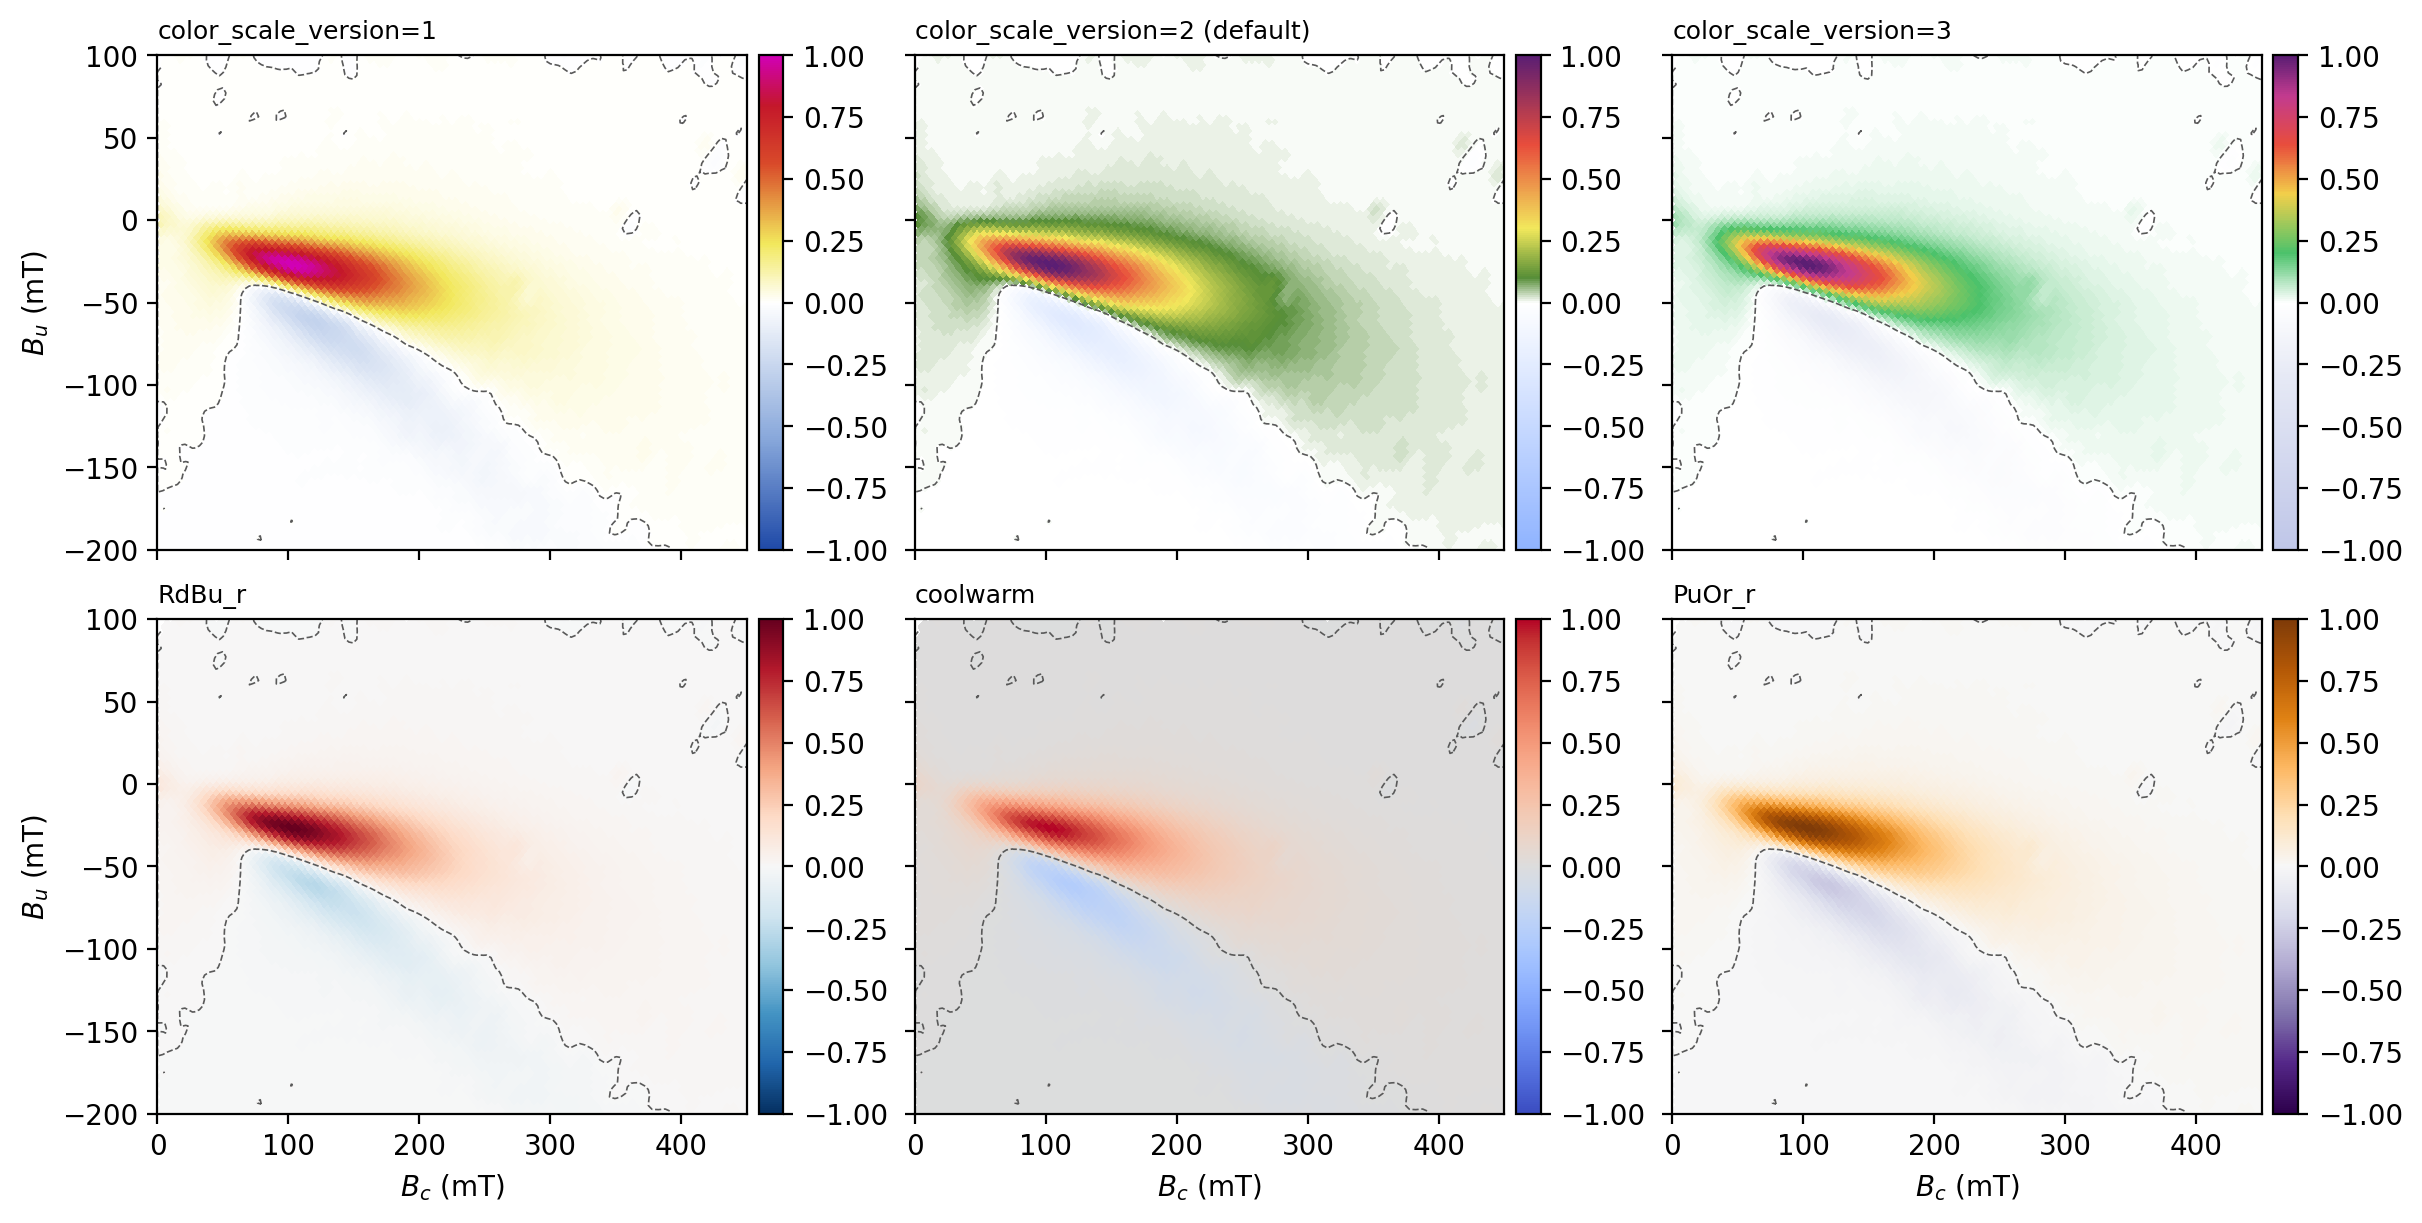

In [13]:
cmaps = [
    ('color_scale_version=1', forc.get_forc_cmap(1)),
    ('color_scale_version=2 (default)', forc.get_forc_cmap(2)),
    ('color_scale_version=3', forc.get_forc_cmap(3)),
    ('RdBu_r', 'RdBu_r'),
    ('coolwarm', 'coolwarm'),
    ('PuOr_r', 'PuOr_r'),
]

cs = forc.process_forc(
    mode='i', path=raw_file, do_regrid=True, B_step=0.005,
    smooth_strength=1.0, plot_hyst=False, plot_rho=False, verbose=False,
)
Ha, Hb, rho = cs['Ha_vals_used'], cs['Hb_vals_used'], cs['rho']
vmax = forc.rho_window_vmax(Ha, Hb, rho, pct=100, Bu_min=-0.15, Bu_max=0.075,
                             Bc_min=0.0, Bc_max=0.6)
Ha_e, Hb_e = np.meshgrid(forc.centers_to_edges(Ha),
                         forc.centers_to_edges(Hb), indexing='ij')
Bc_e, Bu_e = 1e3 * 0.5 * (Hb_e - Ha_e), 1e3 * 0.5 * (Hb_e + Ha_e)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True,
                         sharex=True, sharey=True)
for ax, (name, cmap) in zip(axes.ravel(), cmaps):
    pcm = ax.pcolormesh(Bc_e, Bu_e, rho / vmax, cmap=cmap,
                        vmin=-1, vmax=1, shading='auto')
    # the zero contour: where the sign of rho changes
    ax.contour(1e3 * 0.5 * (Hb[None, :] - Ha[:, None]),
               1e3 * 0.5 * (Hb[None, :] + Ha[:, None]),
               np.nan_to_num(rho), levels=[0.0], colors='0.35',
               linewidths=0.6, linestyles='--')
    ax.set_xlim(0, 450)
    ax.set_ylim(-200, 100)
    ax.set_title(name, fontsize=9, loc='left')
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.02)

for ax in axes[1]:
    ax.set_xlabel(r'$B_c$ (mT)')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$B_u$ (mT)')
plt.show()


The dashed line is the zero contour, drawn identically on every panel. Its apparent
position does not move, but how obvious it is changes a great deal: on the symmetric maps
it separates two limbs of comparable weight, while on the FORC-convention maps it sits
near the edge of a broad, nearly featureless pale region. The negative lobe below the
central peak occupies the same cells in all six panels.

Report the colour scale and the normalization percentile alongside a published diagram.
Both are recorded in the pipeline output, and neither is recoverable from the figure.


## References

- Egli, R. (2013). VARIFORC: An optimized protocol for calculating non-regular first-order reversal curve (FORC) diagrams. *Global and Planetary Change*, 110, 302–320. https://doi.org/10.1016/j.gloplacha.2013.08.003
- Harrison, R. J., & Feinberg, J. M. (2008). FORCinel: An improved algorithm for calculating first-order reversal curve distributions using locally weighted regression smoothing. *Geochemistry, Geophysics, Geosystems*, 9, Q05016. https://doi.org/10.1029/2008GC001987
- Cleveland, W. S. (1979). Robust locally weighted regression and smoothing scatterplots. *Journal of the American Statistical Association*, 74, 829–836. https://doi.org/10.1080/01621459.1979.10481038
- Heslop, D., & Roberts, A. P. (2012). Estimation of significance levels and confidence intervals for first-order reversal curve distributions. *Geochemistry, Geophysics, Geosystems*, 13, Q12Z40. https://doi.org/10.1029/2012GC004115
- Roberts, A. P., Heslop, D., Zhao, X., & Pike, C. R. (2014). Understanding fine magnetic particle systems through use of first-order reversal curve diagrams. *Reviews of Geophysics*, 52, 557–602. https://doi.org/10.1002/2014RG000462